In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.covariance import EllipticEnvelope

import matplotlib.pyplot as plt

In [5]:
# ============================================================
# Paths
# ============================================================

INPUT_PATH = Path("../data/processed/neutral_scoring_prepared/neutral_scoring_input_v1.tsv")

OUTPUT_DIR = Path("../results/one_class_neutral_model_results")
OUTPUT_DIR.mkdir(exist_ok=True)

SCORED_OUTPUT = OUTPUT_DIR / "one_class_neutral_scores_v1.tsv"
THRESHOLD_OUTPUT = OUTPUT_DIR / "one_class_neutral_thresholds_v1.tsv"
ENRICHMENT_OUTPUT = OUTPUT_DIR / "one_class_posthoc_enrichment_v1.tsv"
TOP100_OUTPUT = OUTPUT_DIR / "top_100_one_class_outliers_v1.tsv"

# ============================================================
# Load data
# ============================================================

df = pd.read_csv(INPUT_PATH, sep="\t", low_memory=False)

print("Input shape:", df.shape)
print("\nAnalysis group distribution:")
print(df["analysis_group"].value_counts(dropna=False))

Input shape: (49704, 40)

Analysis group distribution:
analysis_group
unlabeled_or_other            41280
neutral_reference              8284
article_pathogenic_posthoc       84
disease_suspected_posthoc        56
Name: count, dtype: int64


In [6]:
# ============================================================
# Feature engineering
# ============================================================

work = df.copy()

required_cols = [
    "variant_id",
    "position",
    "reference",
    "alternate",
    "validation_label",
    "is_neutral_dataset8",
    "is_pathogenic_dataset9",
    "is_disease_suspected_dataset3",
    "analysis_group",

    "mlc_score",
    "pop_af_max",
    "pop_af_hom_max",
    "pop_af_het_max",
]

missing_cols = [col for col in required_cols if col not in work.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

numeric_cols = [
    "mlc_score",
    "pop_af_max",
    "pop_af_hom_max",
    "pop_af_het_max",
]

for col in numeric_cols:
    work[col] = pd.to_numeric(work[col], errors="coerce")

missing_summary = work[numeric_cols].isna().sum()
missing_summary = missing_summary[missing_summary > 0]

if len(missing_summary) > 0:
    raise ValueError(f"Missing values in numeric features:\n{missing_summary}")

eps = 1e-6

work["rarity_soft"] = -np.log10(work["pop_af_max"] + eps)
work["rarity_soft"] = work["rarity_soft"].clip(lower=0, upper=6)

work["hom_rarity_soft"] = -np.log10(work["pop_af_hom_max"] + eps)
work["hom_rarity_soft"] = work["hom_rarity_soft"].clip(lower=0, upper=6)

work["het_rarity_soft"] = -np.log10(work["pop_af_het_max"] + eps)
work["het_rarity_soft"] = work["het_rarity_soft"].clip(lower=0, upper=6)

work["no_homoplasmic_signal"] = (
    work["pop_af_hom_max"] == 0
).astype(int)

In [7]:
feature_cols = [
    "mlc_score",
    "rarity_soft",
    "hom_rarity_soft",
    "het_rarity_soft",
    "no_homoplasmic_signal",
]

print("\nFeature columns:")
for col in feature_cols:
    print("-", col)

print("\nFeature summary:")
print(work[feature_cols].describe())


Feature columns:
- mlc_score
- rarity_soft
- hom_rarity_soft
- het_rarity_soft
- no_homoplasmic_signal

Feature summary:
          mlc_score   rarity_soft  hom_rarity_soft  het_rarity_soft  \
count  49704.000000  49704.000000     49704.000000     49704.000000   
mean       0.429557      5.462552         5.527284         5.727115   
std        0.332862      0.972211         0.964270         0.559679   
min        0.000000      0.002694         0.002694         0.714830   
25%        0.100340      5.214493         6.000000         6.000000   
50%        0.413910      6.000000         6.000000         6.000000   
75%        0.718360      6.000000         6.000000         6.000000   
max        1.000000      6.000000         6.000000         6.000000   

       no_homoplasmic_signal  
count           49704.000000  
mean                0.765552  
std                 0.423658  
min                 0.000000  
25%                 1.000000  
50%                 1.000000  
75%                 1

In [8]:
# ============================================================
# Split neutral_reference into train and validation
# ============================================================

neutral_df = work[work["analysis_group"] == "neutral_reference"].copy()

print("\nNeutral reference size:", neutral_df.shape)

neutral_train_idx, neutral_val_idx = train_test_split(
    neutral_df.index,
    test_size=0.25,
    random_state=42,
)

print("Neutral train size:", len(neutral_train_idx))
print("Neutral validation size:", len(neutral_val_idx))

work["neutral_split"] = "not_neutral_reference"
work.loc[neutral_train_idx, "neutral_split"] = "neutral_train"
work.loc[neutral_val_idx, "neutral_split"] = "neutral_validation"

print("\nNeutral split distribution:")
print(work["neutral_split"].value_counts())


Neutral reference size: (8284, 44)
Neutral train size: 6213
Neutral validation size: 2071

Neutral split distribution:
neutral_split
not_neutral_reference    41420
neutral_train             6213
neutral_validation        2071
Name: count, dtype: int64


In [9]:
# ============================================================
# One-class model helper
# ============================================================

def fit_score_isolation_forest(data, train_idx, feature_cols, model_name):
    X_train = data.loc[train_idx, feature_cols]
    X_all = data[feature_cols]

    model = Pipeline([
        ("scaler", RobustScaler()),
        ("model", IsolationForest(
            n_estimators=500,
            contamination="auto",
            random_state=42,
            n_jobs=-1,
        )),
    ])

    model.fit(X_train)

    # decision_function: larger = more normal
    normality_score = model.decision_function(X_all)

    # outlier score: larger = more out-of-neutral-domain
    outlier_score = -normality_score

    return outlier_score, model


def fit_score_elliptic_envelope(data, train_idx, feature_cols, model_name):
    X_train = data.loc[train_idx, feature_cols]
    X_all = data[feature_cols]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", EllipticEnvelope(
            contamination=0.05,
            random_state=42,
            support_fraction=None,
        )),
    ])

    model.fit(X_train)

    # decision_function: larger = more normal
    normality_score = model.decision_function(X_all)

    # outlier score: larger = more out-of-neutral-domain
    outlier_score = -normality_score

    return outlier_score, model

In [10]:
# ============================================================
# Fit models
# ============================================================

scored = work.copy()

score_specs = {}

iso_score, iso_model = fit_score_isolation_forest(
    scored,
    neutral_train_idx,
    feature_cols,
    model_name="isolation_forest",
)

scored["isolation_forest_outlier_score"] = iso_score
score_specs["isolation_forest"] = {
    "score_col": "isolation_forest_outlier_score",
    "model": iso_model,
}

ell_score, ell_model = fit_score_elliptic_envelope(
    scored,
    neutral_train_idx,
    feature_cols,
    model_name="elliptic_envelope",
)

scored["elliptic_envelope_outlier_score"] = ell_score
score_specs["elliptic_envelope"] = {
    "score_col": "elliptic_envelope_outlier_score",
    "model": ell_model,
}

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-14.250586794294659 > -42.289599133740097). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-18.215564620784470 > -41.867784193425784). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-42.892732567497703 > -44.956513765721901

In [11]:
# ============================================================
# Threshold calibration on held-out neutral_validation
# ============================================================

threshold_rows = []

validation_mask = scored["neutral_split"] == "neutral_validation"

for model_name, spec in score_specs.items():
    score_col = spec["score_col"]

    validation_scores = scored.loc[validation_mask, score_col]

    for q in [0.90, 0.95, 0.99]:
        threshold_name = f"T{int(q * 100)}"
        threshold = validation_scores.quantile(q)

        flag_col = f"{model_name}_above_{threshold_name}"

        scored[flag_col] = (
            scored[score_col] > threshold
        ).astype(int)

        n_val_above = int(scored.loc[validation_mask, flag_col].sum())
        frac_val_above = float(scored.loc[validation_mask, flag_col].mean())

        threshold_rows.append({
            "model_name": model_name,
            "score_col": score_col,
            "threshold_name": threshold_name,
            "validation_neutral_quantile": q,
            "threshold_value": threshold,
            "n_validation_neutral_above": n_val_above,
            "fraction_validation_neutral_above": frac_val_above,
        })

threshold_df = pd.DataFrame(threshold_rows)

print("\nThresholds:")
print(threshold_df)

threshold_df.to_csv(THRESHOLD_OUTPUT, sep="\t", index=False)
print("\nSaved thresholds:", THRESHOLD_OUTPUT)


Thresholds:
          model_name                        score_col threshold_name  \
0   isolation_forest   isolation_forest_outlier_score            T90   
1   isolation_forest   isolation_forest_outlier_score            T95   
2   isolation_forest   isolation_forest_outlier_score            T99   
3  elliptic_envelope  elliptic_envelope_outlier_score            T90   
4  elliptic_envelope  elliptic_envelope_outlier_score            T95   
5  elliptic_envelope  elliptic_envelope_outlier_score            T99   

   validation_neutral_quantile  threshold_value  n_validation_neutral_above  \
0                         0.90         0.074633                         207   
1                         0.95         0.118380                         104   
2                         0.99         0.160127                          21   
3                         0.90       -81.009590                         206   
4                         0.95        -8.425259                         104   
5       

In [12]:
# ============================================================
# Post-hoc enrichment
# ============================================================

analysis_groups = [
    "neutral_reference",
    "unlabeled_or_other",
    "article_pathogenic_posthoc",
    "disease_suspected_posthoc",
]

expected_fraction = {
    "T90": 0.10,
    "T95": 0.05,
    "T99": 0.01,
}

enrichment_rows = []

for model_name, spec in score_specs.items():
    for threshold_name in ["T90", "T95", "T99"]:
        flag_col = f"{model_name}_above_{threshold_name}"
        expected = expected_fraction[threshold_name]

        for group in analysis_groups:
            group_mask = scored["analysis_group"] == group

            n_group = int(group_mask.sum())
            n_above = int(scored.loc[group_mask, flag_col].sum())
            frac_above = n_above / n_group if n_group > 0 else np.nan

            enrichment_rows.append({
                "model_name": model_name,
                "threshold_name": threshold_name,
                "analysis_group": group,
                "n_group": n_group,
                "n_above_threshold": n_above,
                "fraction_above_threshold": frac_above,
                "expected_validation_neutral_fraction": expected,
                "fold_enrichment_vs_expected": (
                    frac_above / expected if expected > 0 else np.nan
                ),
            })

enrichment_df = pd.DataFrame(enrichment_rows)

print("\nPost-hoc enrichment:")
print(enrichment_df)

enrichment_df.to_csv(ENRICHMENT_OUTPUT, sep="\t", index=False)
print("\nSaved enrichment:", ENRICHMENT_OUTPUT)


Post-hoc enrichment:
           model_name threshold_name              analysis_group  n_group  \
0    isolation_forest            T90           neutral_reference     8284   
1    isolation_forest            T90          unlabeled_or_other    41280   
2    isolation_forest            T90  article_pathogenic_posthoc       84   
3    isolation_forest            T90   disease_suspected_posthoc       56   
4    isolation_forest            T95           neutral_reference     8284   
5    isolation_forest            T95          unlabeled_or_other    41280   
6    isolation_forest            T95  article_pathogenic_posthoc       84   
7    isolation_forest            T95   disease_suspected_posthoc       56   
8    isolation_forest            T99           neutral_reference     8284   
9    isolation_forest            T99          unlabeled_or_other    41280   
10   isolation_forest            T99  article_pathogenic_posthoc       84   
11   isolation_forest            T99   disease_suspect

In [13]:
# ============================================================
# Add ranks and percentiles
# ============================================================

for model_name, spec in score_specs.items():
    score_col = spec["score_col"]

    scored[f"{model_name}_rank"] = (
        scored[score_col]
        .rank(method="min", ascending=False)
        .astype(int)
    )

    scored[f"{model_name}_percentile"] = (
        scored[score_col]
        .rank(method="average", pct=True)
    )

In [14]:
# ============================================================
# Save scored table
# ============================================================

base_cols = [
    "variant_id",
    "position",
    "reference",
    "alternate",
    "validation_label",
    "is_neutral_dataset8",
    "is_pathogenic_dataset9",
    "is_disease_suspected_dataset3",
    "analysis_group",
    "neutral_split",
]

feature_output_cols = feature_cols + [
    "pop_af_max",
    "pop_af_hom_max",
    "pop_af_het_max",
]

score_output_cols = []

for model_name in score_specs:
    score_output_cols.extend([
        f"{model_name}_outlier_score",
        f"{model_name}_rank",
        f"{model_name}_percentile",
        f"{model_name}_above_T90",
        f"{model_name}_above_T95",
        f"{model_name}_above_T99",
    ])

output_cols = base_cols + feature_output_cols + score_output_cols

scored[output_cols].to_csv(SCORED_OUTPUT, sep="\t", index=False)

print("\nSaved scored table:")
print(SCORED_OUTPUT)


Saved scored table:
../results/one_class_neutral_model_results/one_class_neutral_scores_v1.tsv


In [15]:
# ============================================================
# Top-100 for each model
# ============================================================

top_rows = []

for model_name, spec in score_specs.items():
    score_col = spec["score_col"]

    top = (
        scored[output_cols]
        .sort_values(score_col, ascending=False)
        .head(100)
        .copy()
    )

    top["model_name"] = model_name
    top["top_rank"] = np.arange(1, top.shape[0] + 1)

    top_rows.append(top)

top_100_all = pd.concat(top_rows, axis=0)

top_100_all.to_csv(TOP100_OUTPUT, sep="\t", index=False)

print("\nSaved top-100:")
print(TOP100_OUTPUT)

print("\nTop-20 Isolation Forest:")
print(
    top_100_all[top_100_all["model_name"] == "isolation_forest"][
        [
            "top_rank",
            "variant_id",
            "analysis_group",
            "isolation_forest_outlier_score",
            "mlc_score",
            "rarity_soft",
            "pop_af_max",
            "no_homoplasmic_signal",
        ]
    ].head(20)
)

print("\nTop-20 Elliptic Envelope:")
print(
    top_100_all[top_100_all["model_name"] == "elliptic_envelope"][
        [
            "top_rank",
            "variant_id",
            "analysis_group",
            "elliptic_envelope_outlier_score",
            "mlc_score",
            "rarity_soft",
            "pop_af_max",
            "no_homoplasmic_signal",
        ]
    ].head(20)
)


Saved top-100:
../results/one_class_neutral_model_results/top_100_one_class_outliers_v1.tsv

Top-20 Isolation Forest:
       top_rank  variant_id      analysis_group  \
9028          1   m.3010G>A   neutral_reference   
39311         2  m.13105A>G   neutral_reference   
22558         3   m.7521G>A   neutral_reference   
9055          4   m.3019G>A  unlabeled_or_other   
9089          5   m.3030A>G  unlabeled_or_other   
29947         6   m.9984G>A  unlabeled_or_other   
21613         7   m.7206G>A  unlabeled_or_other   
29941         8   m.9982G>A  unlabeled_or_other   
22171         9   m.7392G>A  unlabeled_or_other   
28345        10   m.9450G>A  unlabeled_or_other   
18628        11   m.6211G>A  unlabeled_or_other   
904          12    m.302A>C  unlabeled_or_other   
25686        13   m.8564C>T  unlabeled_or_other   
19825        14   m.6610G>A  unlabeled_or_other   
27916        15   m.9307G>A  unlabeled_or_other   
21154        16   m.7053G>A  unlabeled_or_other   
19723        1

In [16]:
analysis_group_order = [
    "neutral_reference",
    "unlabeled_or_other",
    "article_pathogenic_posthoc",
    "disease_suspected_posthoc",
]

analysis_group_labels = {
    "neutral_reference": "Neutral reference",
    "unlabeled_or_other": "Unlabeled / other",
    "article_pathogenic_posthoc": "Article pathogenic post-hoc",
    "disease_suspected_posthoc": "Disease suspected post-hoc",
}


def plot_one_class_score_distribution(scored, threshold_df, model_name):
    score_col = f"{model_name}_outlier_score"

    plt.figure(figsize=(10, 6))

    for group in analysis_group_order:
        subset = scored.loc[
            scored["analysis_group"] == group,
            score_col
        ].dropna()

        if len(subset) == 0:
            continue

        plt.hist(
            subset,
            bins=60,
            density=True,
            alpha=0.45,
            label=f"{analysis_group_labels[group]} (n={len(subset)})",
        )

    for threshold_name in ["T90", "T95", "T99"]:
        threshold_value = threshold_df.loc[
            (threshold_df["model_name"] == model_name)
            & (threshold_df["threshold_name"] == threshold_name),
            "threshold_value"
        ].iloc[0]

        plt.axvline(
            threshold_value,
            linestyle="--",
            linewidth=1,
            label=threshold_name,
        )

    plt.xlabel("Out-of-neutral-domain score")
    plt.ylabel("Density")
    plt.title(f"One-class score distribution: {model_name}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_one_class_enrichment(enrichment_df, model_name, threshold_name):
    plot_df = enrichment_df[
        (enrichment_df["model_name"] == model_name)
        & (enrichment_df["threshold_name"] == threshold_name)
    ].copy()

    plot_df = (
        plot_df
        .set_index("analysis_group")
        .loc[analysis_group_order]
        .reset_index()
    )

    x = np.arange(plot_df.shape[0])
    y = plot_df["fraction_above_threshold"].values

    plt.figure(figsize=(9, 5))
    plt.bar(x, y)

    plt.axhline(
        {"T90": 0.10, "T95": 0.05, "T99": 0.01}[threshold_name],
        linestyle="--",
        linewidth=1,
        label=f"Validation-neutral expectation: {threshold_name}",
    )

    plt.xticks(
        x,
        [analysis_group_labels[g] for g in plot_df["analysis_group"]],
        rotation=30,
        ha="right",
    )

    plt.ylabel("Fraction above threshold")
    plt.title(f"{model_name}: fraction above {threshold_name}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_one_class_top_tail(scored, threshold_df, model_name, top_n=1000):
    score_col = f"{model_name}_outlier_score"

    top_df = (
        scored
        .sort_values(score_col, ascending=False)
        .head(top_n)
        .copy()
    )

    top_df["rank_in_top"] = np.arange(1, top_df.shape[0] + 1)

    plt.figure(figsize=(10, 5))

    plt.plot(
        top_df["rank_in_top"],
        top_df[score_col],
        linewidth=1,
    )

    for threshold_name in ["T90", "T95", "T99"]:
        threshold_value = threshold_df.loc[
            (threshold_df["model_name"] == model_name)
            & (threshold_df["threshold_name"] == threshold_name),
            "threshold_value"
        ].iloc[0]

        plt.axhline(
            threshold_value,
            linestyle="--",
            linewidth=1,
            label=threshold_name,
        )

    plt.xlabel(f"Rank among top {top_n} variants")
    plt.ylabel("Out-of-neutral-domain score")
    plt.title(f"Top-tail profile: {model_name}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

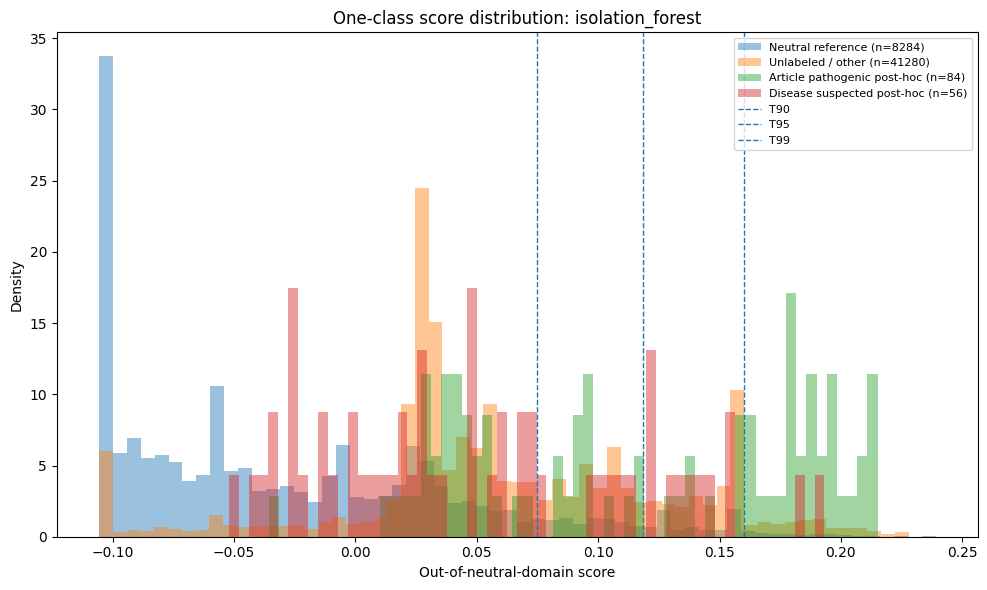

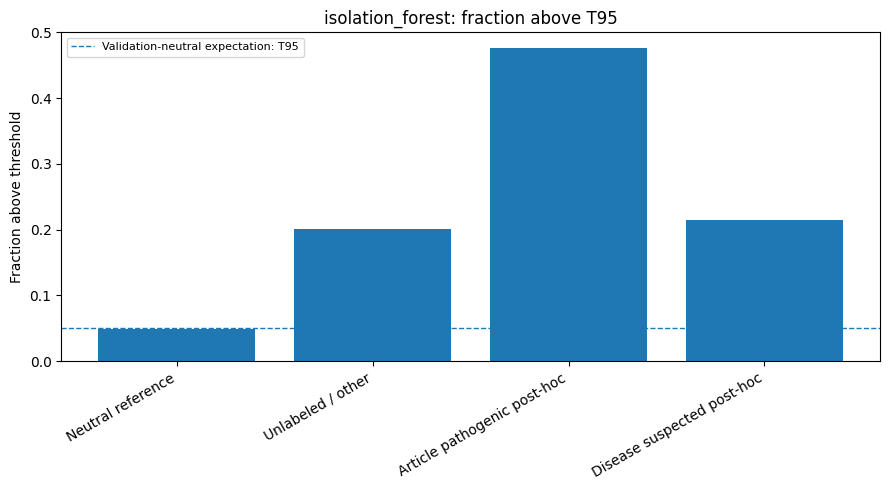

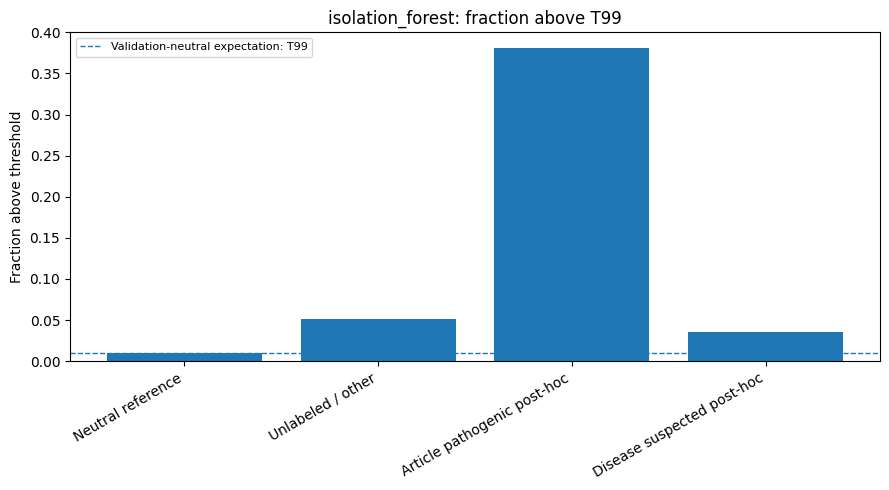

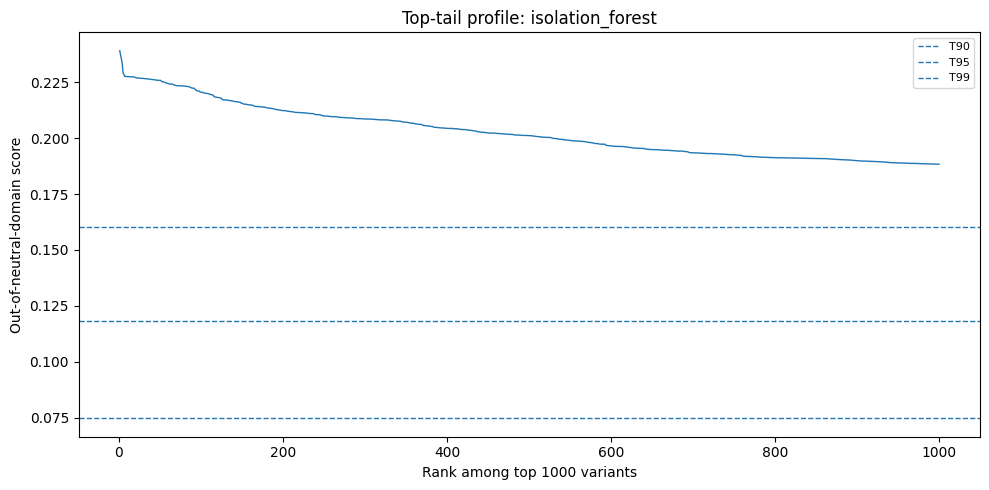

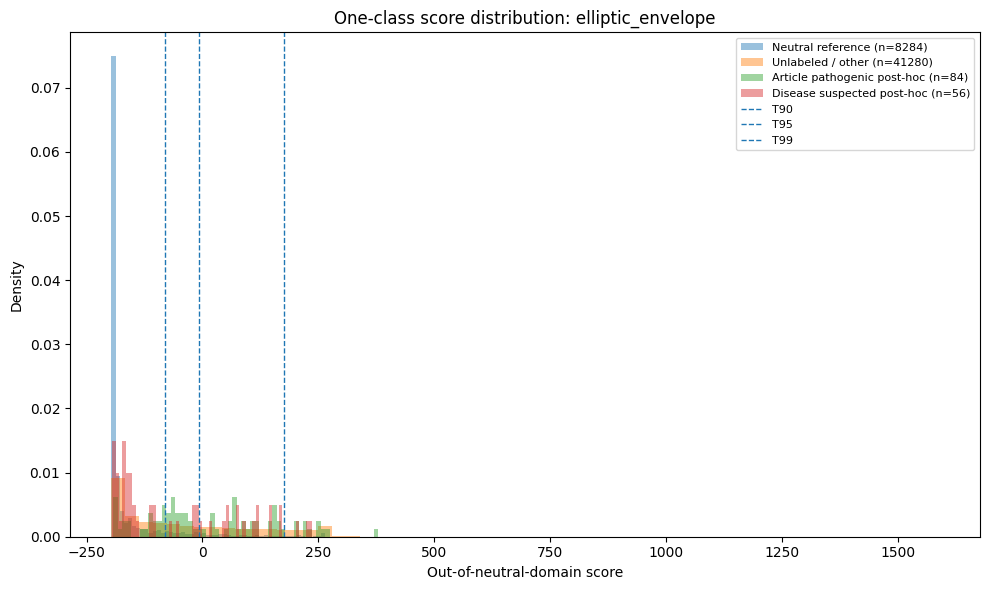

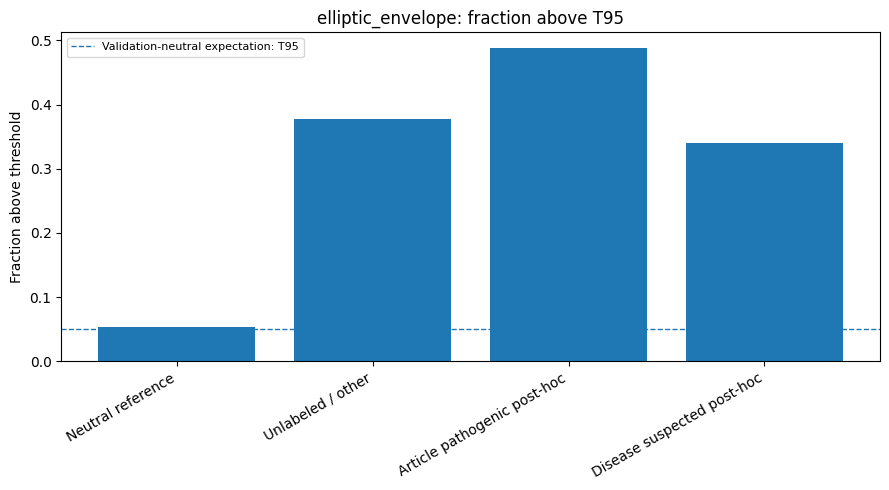

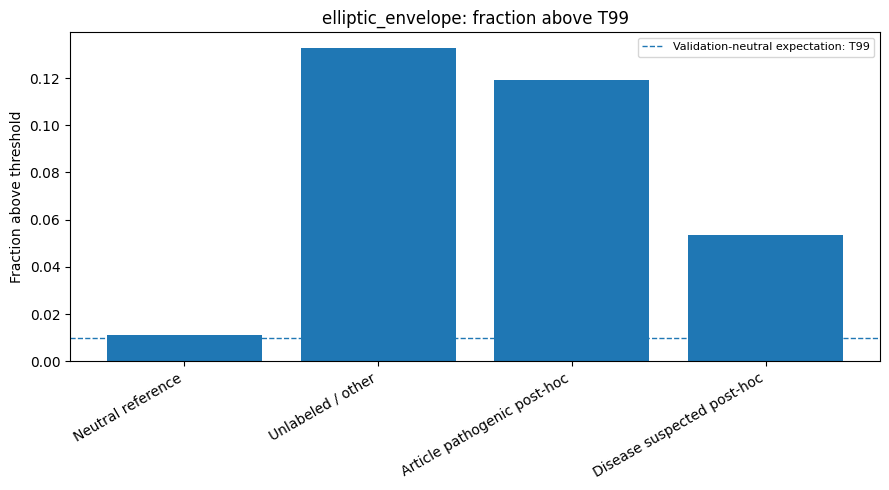

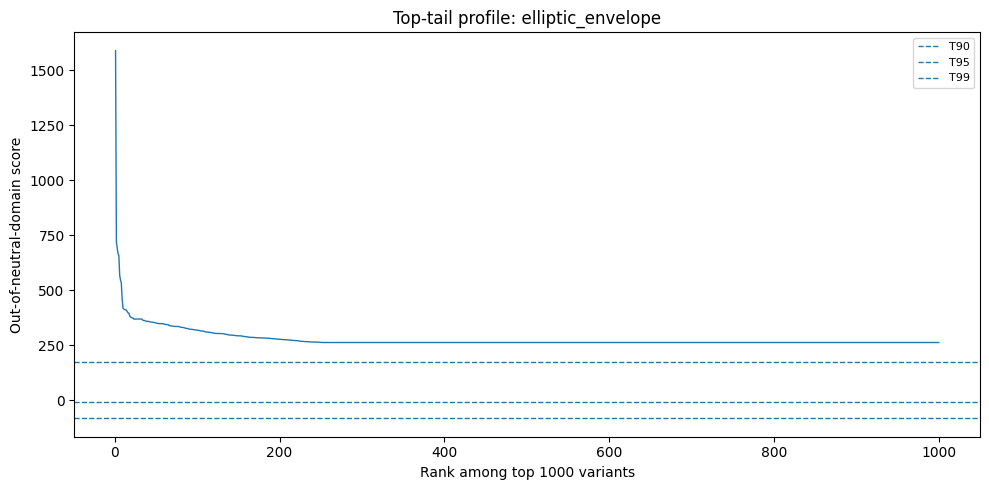

In [17]:
for model_name in ["isolation_forest", "elliptic_envelope"]:
    plot_one_class_score_distribution(scored, threshold_df, model_name)
    plot_one_class_enrichment(enrichment_df, model_name, "T95")
    plot_one_class_enrichment(enrichment_df, model_name, "T99")
    plot_one_class_top_tail(scored, threshold_df, model_name, top_n=1000)